In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
df = pd.read_csv("/data/processed/mall_customers_clean.csv")
df.head()


,customer_id,gender,age,income,spending_score
0,16342,Male,25,140537,76
1,21077,Female,34,55650,58
2,34306,Female,49,33790,8
3,34026,Female,37,171171,98
4,42620,Female,26,66042,54


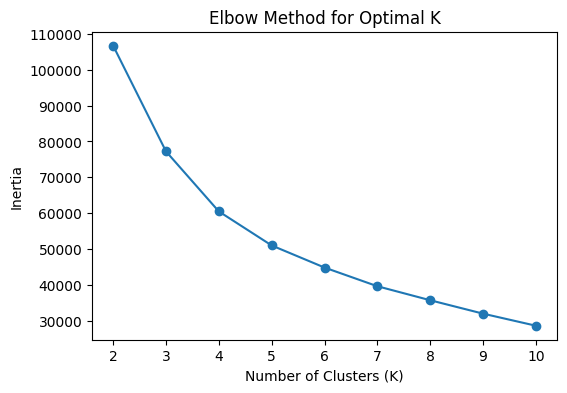

In [6]:
features = ['age', 'income', 'spending_score']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(6,4))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

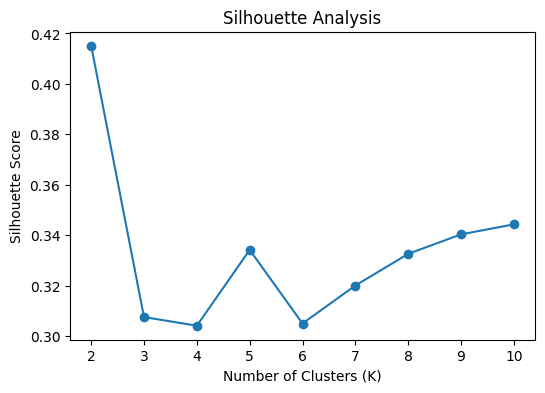

In [7]:
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
plt.figure(figsize=(6,4))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()


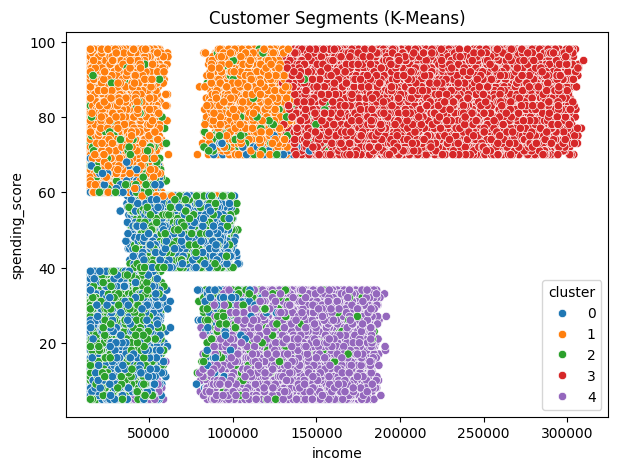

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="income",
    y="spending_score",
    hue="cluster",
    palette="tab10",
    data=df
)
plt.title("Customer Segments (K-Means)")
plt.show()

In [11]:
cluster_summary = (
    df
    .groupby("cluster")
    .agg(
        avg_income=("income", "mean"),
        avg_spending=("spending_score", "mean"),
        count=("customer_id", "count")
    )
)

cluster_summary

,avg_income,avg_spending,count
cluster,,,
0,60589.243629,42.483677,16480
1,48595.775204,81.435534,7469
2,62329.198848,43.184660,13885
3,217526.280523,84.201392,5889
4,137541.631034,18.371674,6277


In [12]:
segment_map = {
    0: "Low Income - Low Spending",
    1: "High Income - High Spending",
    2: "Low Income - High Spending",
    3: "High Income - Low Spending",
    4: "Average Customers"
}

df["segment"] = df["cluster"].map(segment_map)


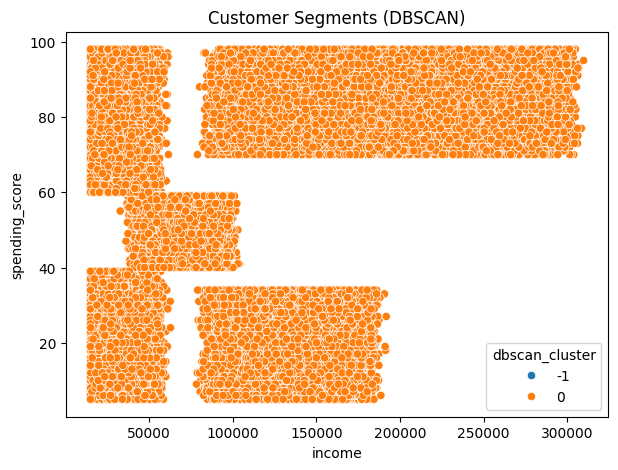

In [14]:
dbscan = DBSCAN(eps=0.6, min_samples=5)
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="income",
    y="spending_score",
    hue="dbscan_cluster",
    palette="tab10",
    data=df
)
plt.title("Customer Segments (DBSCAN)")
plt.show()

In [15]:
import os

output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

df.to_csv(os.path.join(output_dir, "/data/processed/mall_customers_segmented.csv"), index=False)

### Segmentation Insights

1. High-income high-spending customers represent premium buyers.
2. High-income low-spending customers are ideal upsell targets.
3. Low-income high-spending customers are value-driven loyal users.
4. Low-income low-spending customers show low engagement.
5. Clustering enables targeted marketing and personalized recommendations.
